# 05 Simplified Market-Making Simulation

This notebook is a compact extension to the market microstructure project:

- A simplified inventory-aware market-making simulation under visible-order-book assumptions.

It studies spread-based quoting, inventory-aware quote adjustment, touch-based fills, inventory/cash accounting, marked PnL, risk controls, and limited descriptive sensitivity. 

## 1. Objective and Scope

Questions:

1. Under simplified fill assumptions, what fill rate, inventory exposure, spread-capture proxy, marked PnL, and maximum inventory exposure does fixed symmetric quoting produce?
2. With the same data and parameters except inventory skew, does inventory-aware quoting reduce inventory without materially damaging fill rate and spread capture?
3. How sensitive are the results to quoted half-spread, order size, and inventory-skew strength?

The input is LOB snapshot data. The simulation does not observe queue position, order priority, latency, hidden liquidity, cancellations, true order arrivals, or calibrated market impact.

In [1]:
from pathlib import Path

import pandas as pd
from IPython.display import Image, display

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

TABLE_DIR = PROJECT_ROOT / "reports" / "selected_tables"
FIGURE_DIR = PROJECT_ROOT / "reports" / "figures"

baseline = pd.read_csv(TABLE_DIR / "market_making_baseline_summary.csv")
comparison = pd.read_csv(TABLE_DIR / "market_making_matched_comparison.csv")
sensitivity = pd.read_csv(TABLE_DIR / "market_making_sensitivity.csv")

## 2. Load and Validate Data


In [2]:
data_summary = pd.read_csv(TABLE_DIR / "dataset_summary.csv")
mm_scope = baseline[["start_time", "end_time"]].drop_duplicates()
display(data_summary[data_summary["item"].isin(["Asset", "Sampling frequency", "Quantity unit"])])
display(mm_scope)

,item,value
0,Asset,BTC
6,Sampling frequency,Dataset filename indicates 1 second; observed ...
16,Quantity unit,dataset-provided quantity units


,start_time,end_time
0,2021-04-07 11:32:47.122161+00:00,2021-04-07 18:29:22.626760+00:00


## 3. Simulation Assumptions

Quantity units are dataset-provided units, not confirmed BTC. The fill model is a deterministic one-next-snapshot touch proxy: quotes are formed at time t and evaluated at time t+1; a bid quote fills if the t+1 observed best ask is at or below the bid quote, and an ask quote fills if the t+1 observed best bid is at or above the ask quote.

In [3]:
assumption_cols = [
    "strategy",
    "half_spread_bps",
    "order_size",
    "inventory_skew_bps",
    "max_inventory",
    "maker_fee_bps",
    "fill_model",
    "mark_price_method",
    "order_size_to_average_visible_depth",
]
display(baseline[assumption_cols])

,strategy,half_spread_bps,order_size,inventory_skew_bps,max_inventory,maker_fee_bps,fill_model,mark_price_method,order_size_to_average_visible_depth
0,symmetric,1.0,500.0,0.0,12500.0,0.5,touch,mid,0.001629
1,inventory_aware,1.0,500.0,2.0,12500.0,0.5,touch,mid,0.001629


## 4. Baseline: Symmetric Quotes

Symmetric quoting uses the same half-spread on both sides of the mid-price and no inventory skew. Inventory limits still prevent adding risk beyond the configured maximum.

In [4]:
summary_cols = [
    "strategy",
    "total_marked_pnl",
    "pnl_after_liquidation",
    "fill_rate",
    "trade_count",
    "ending_inventory",
    "average_absolute_inventory",
    "maximum_absolute_inventory",
    "turnover",
    "gross_spread_capture_proxy",
    "inventory_revaluation_pnl",
    "fees",
]
display(baseline.loc[baseline["strategy"] == "symmetric", summary_cols])

,strategy,total_marked_pnl,pnl_after_liquidation,fill_rate,trade_count,ending_inventory,average_absolute_inventory,maximum_absolute_inventory,turnover,gross_spread_capture_proxy,inventory_revaluation_pnl,fees
0,symmetric,-2.479374e+07,-2.493344e+07,0.216448,2095,12500.0,6660.1,12500.0,5.910779e+10,5.992820e+06,-2.783117e+07,2.955389e+06


## 5. Inventory-Aware Quotes

Inventory-aware quoting keeps the same half-spread, order size, fee, limit, sample window, and fill model. The only intentional change is inventory skew: positive inventory shifts both quotes lower to discourage additional buying and encourage selling; negative inventory shifts quotes higher.

In [5]:
display(baseline.loc[baseline["strategy"] == "inventory_aware", summary_cols])

,strategy,total_marked_pnl,pnl_after_liquidation,fill_rate,trade_count,ending_inventory,average_absolute_inventory,maximum_absolute_inventory,turnover,gross_spread_capture_proxy,inventory_revaluation_pnl,fees
1,inventory_aware,-1.837527e+07,-1.843674e+07,0.2149,2149,5500.0,1864.3,6500.0,6.062653e+10,5.977279e+06,-21321217.5,3.031327e+06


## 6. Matched Comparison

Lower marked PnL is not hidden, and lower inventory is not treated as sufficient by itself. The comparison shows inventory, fill rate, spread-capture proxy, revaluation, fees, and ending inventory together.

In [6]:
display(comparison)

,metric,symmetric,inventory_aware,difference
0,total_marked_pnl,-2.479374e+07,-1.837527e+07,6.418473e+06
1,pnl_after_liquidation,-2.493344e+07,-1.843674e+07,6.496707e+06
2,fill_rate,2.164480e-01,2.149000e-01,-1.547980e-03
3,trade_count,2.095000e+03,2.149000e+03,5.400000e+01
4,average_absolute_inventory,6.660100e+03,1.864300e+03,-4.795800e+03
5,maximum_absolute_inventory,1.250000e+04,6.500000e+03,-6.000000e+03
6,ending_inventory,1.250000e+04,5.500000e+03,-7.000000e+03
7,gross_spread_capture_proxy,5.992820e+06,5.977279e+06,-1.554188e+04
8,inventory_revaluation_pnl,-2.783117e+07,-2.132122e+07,6.509952e+06
9,fees,2.955389e+06,3.031327e+06,7.593715e+04


## 7. Quotes, Inventory, and Marked PnL

The figures are generated from the same fixed inventory-aware baseline run. PnL is marked in dataset-provided notional units.

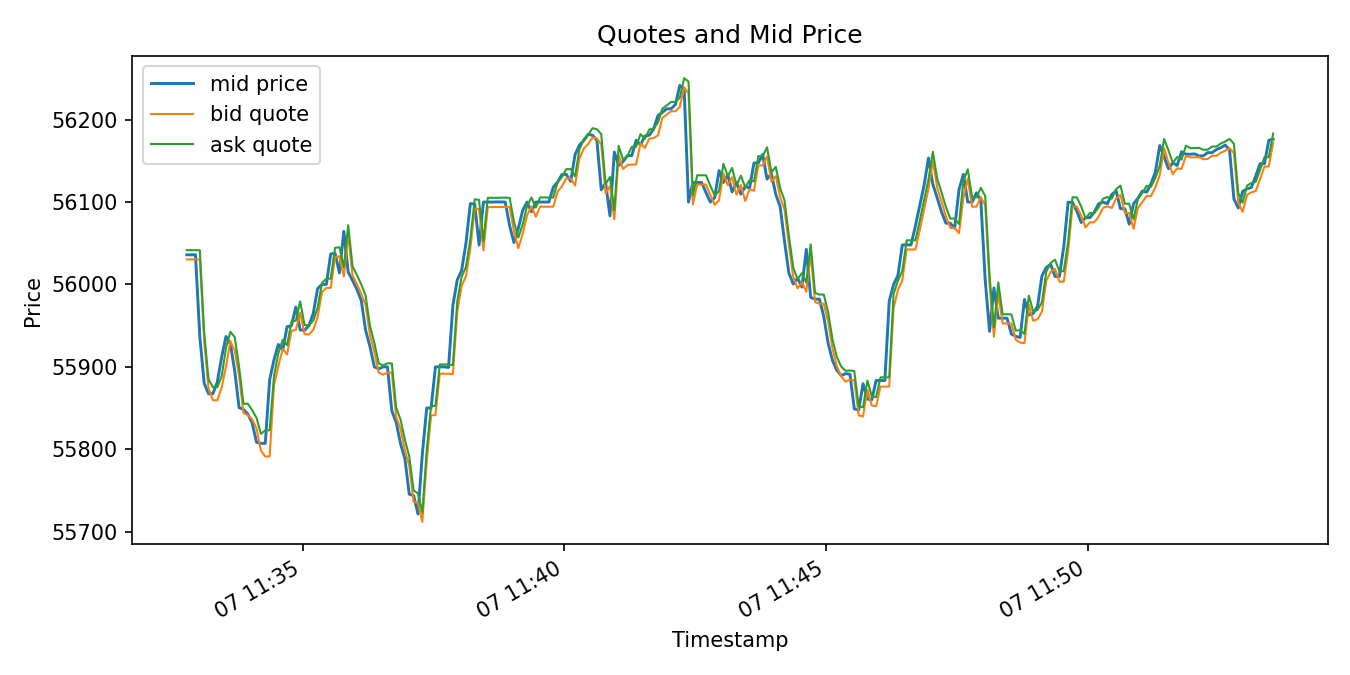

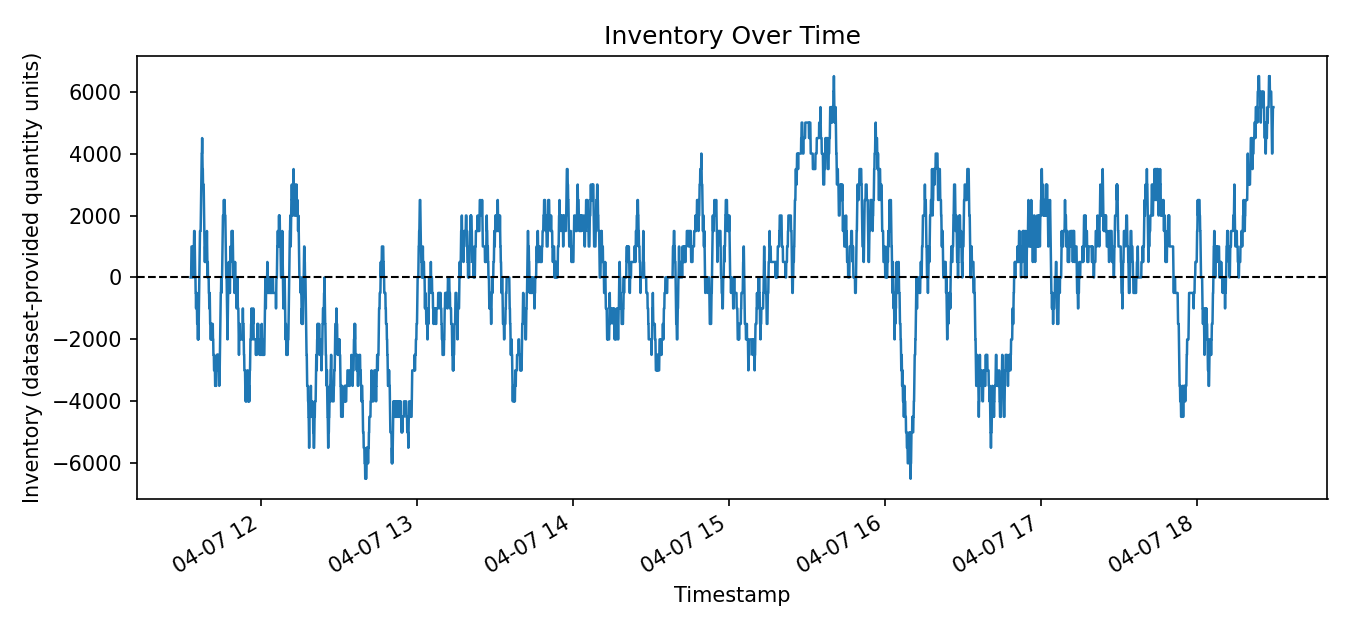

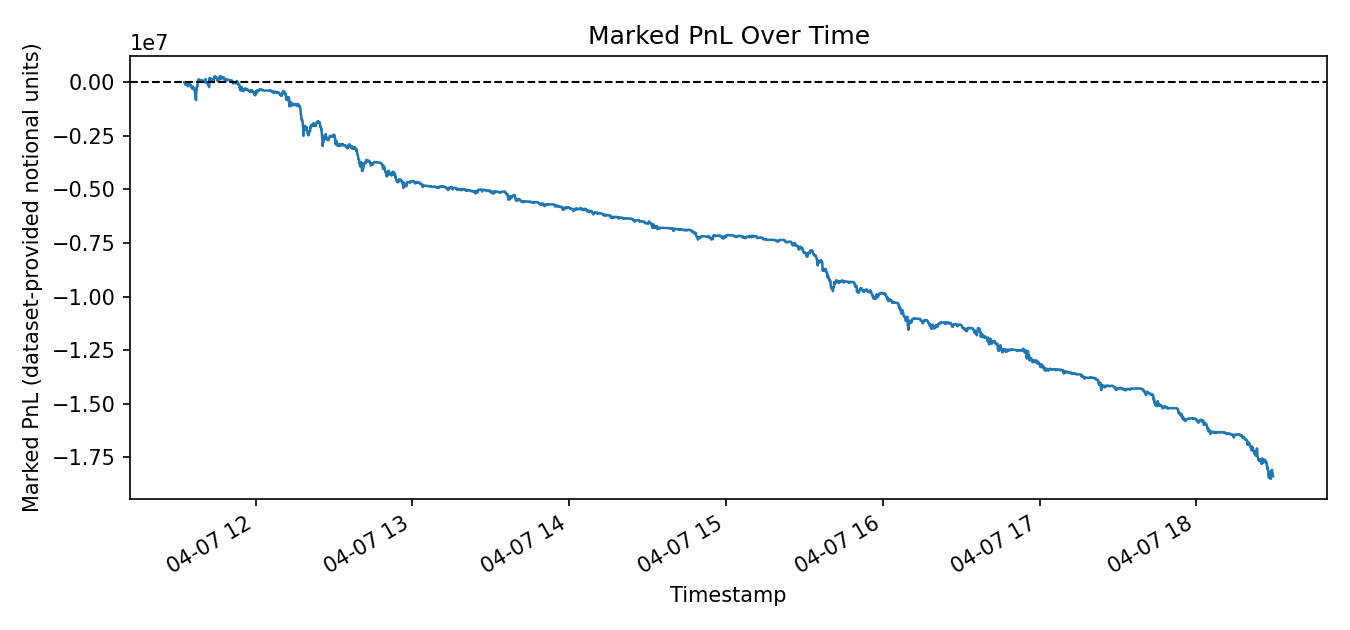

In [7]:
display(Image(filename=str(FIGURE_DIR / "market_making_quotes.png")))
display(Image(filename=str(FIGURE_DIR / "market_making_inventory.png")))
display(Image(filename=str(FIGURE_DIR / "market_making_pnl.png")))

## 8. Limited Sensitivity Analysis

The sensitivity analysis is descriptive and is not used to select a favorable parameter set. It varies one parameter at a time around the predefined inventory-aware baseline.

,sensitivity_parameter,sensitivity_value,total_marked_pnl,fill_rate,average_absolute_inventory,maximum_absolute_inventory,order_size_to_average_visible_depth
0,half_spread_bps,0.5,-2.088430e+07,0.258700,2063.8,8500.0,0.001629
1,half_spread_bps,1.0,-1.837527e+07,0.214900,1864.3,6500.0,0.001629
2,half_spread_bps,2.0,-8.109596e+06,0.144400,1241.2,4500.0,0.001629
3,half_spread_bps,4.0,-2.823401e+06,0.058100,1428.4,4500.0,0.001629
4,inventory_skew_bps,0.0,-2.479374e+07,0.216448,6660.1,12500.0,0.001629
5,inventory_skew_bps,1.0,-1.777888e+07,0.215300,2439.0,9000.0,0.001629
6,inventory_skew_bps,2.0,-1.837527e+07,0.214900,1864.3,6500.0,0.001629
7,inventory_skew_bps,4.0,-1.808700e+07,0.213600,1345.3,5500.0,0.001629
8,order_size,250.0,-8.889438e+06,0.215300,1219.5,4500.0,0.000815
9,order_size,500.0,-1.837527e+07,0.214900,1864.3,6500.0,0.001629


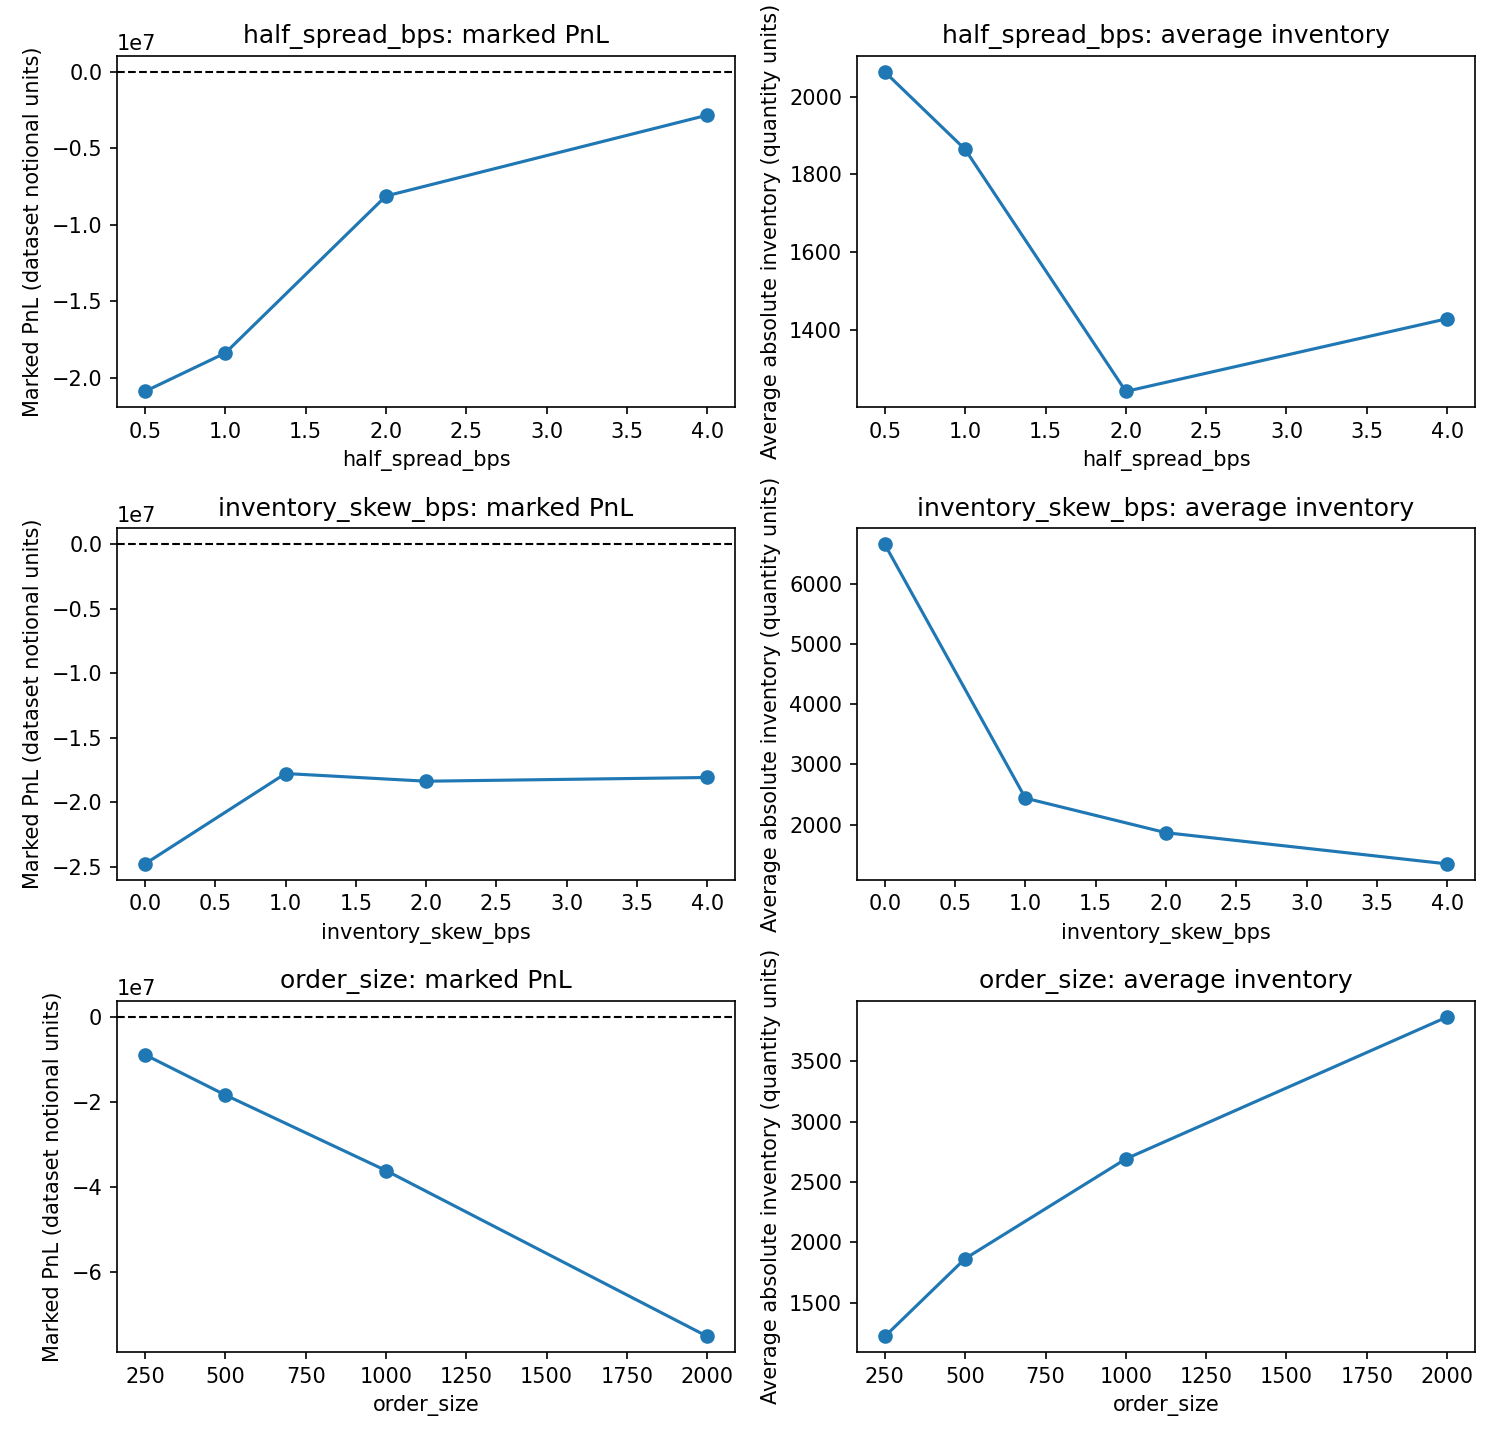

In [8]:
sensitivity_cols = [
    "sensitivity_parameter",
    "sensitivity_value",
    "total_marked_pnl",
    "fill_rate",
    "average_absolute_inventory",
    "maximum_absolute_inventory",
    "order_size_to_average_visible_depth",
]
display(sensitivity[sensitivity_cols])
display(Image(filename=str(FIGURE_DIR / "market_making_sensitivity.png")))

## 9. Main Findings

In the retained fixed sample, inventory-aware quoting reduces average and maximum inventory exposure versus symmetric quoting. Fill rate is similar but slightly lower. Both baseline variants produce negative marked PnL under the stated assumptions; the inventory-aware result is less negative mainly because inventory revaluation is less adverse, not because the simulation proves a positive spread-capture result.

Wider quoted half-spreads reduce fill rate and inventory exposure in the sensitivity table. Larger order size increases inventory exposure and makes marked PnL more negative in this sample. Inventory skew materially changes inventory exposure, but the PnL effect remains assumption- and sample-dependent.

## 10. Limitations

- Snapshot data rather than message-level order events.
- No queue position, order priority, latency, hidden liquidity, or cancel/replace dynamics.
- Simplified touch fill assumption.
- Dataset-provided quantity units.
- No calibrated fees, rebates, or market impact.
